# Using Conditional Conformal Prediction to get adaptative prediction intervals
## Tutorial and comparison with other methods on <i>"Communities and Crimes"</i> Dataset.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/scikit-learn-contrib/MAPIE/blob/master/notebooks/regression/tutorial_ccp_CandC.ipynb)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from tqdm import tqdm
from urllib.request import urlopen
from copy import deepcopy

from lightgbm import LGBMRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances


from mapie.conformity_scores import AbsoluteConformityScore
from mapie.conditional_conformal_prediction import ConditionalSplitConformalRegressor
from mapie.regression import (
    ConformalizedQuantileRegressor,
    SplitConformalRegressor,
)

import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)

random_state = 1
np.random.seed(random_state)

## Getting the data

In [2]:
with urlopen("https://archive.ics.uci.edu/ml/machine-learning-databases/communities/communities.names", timeout=30) as response:
    names_text = response.read().decode("latin-1")
column_names = [
    line.strip().split()[1]
    for line in names_text.splitlines()
    if line.strip().startswith("@attribute")
]
communities_and_crime = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/communities/communities.data", names=column_names, na_values="?")
y = communities_and_crime["ViolentCrimesPerPop"].to_numpy()
X = communities_and_crime.drop(columns=["communityname", "ViolentCrimesPerPop"])
X = X.loc[:, X.isna().sum() == 0]
col_names = list(X.columns)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.to_numpy())

We normalize the data, to simplify the following (even if the used model doesn't requires it)

In [3]:
def generate_data(seed, n_train, n_calib, n_test):
    """
    Return a new split (x_train, y_train, x_calib, y_calib, x_test, y_test)
    of the dataset, based on the ``seed`` value.
    """
    np.random.seed(seed)
    if n_train+n_calib+n_test > len(X):
        raise ValueError(
            f"n_train + n_calib + n_test = {n_train} + {n_calib} + {n_test}"
            f" = {n_train+n_calib+n_test} > len(total_dataset) = {len(X)}")
    
    indexes = list(range(len(X)))
    train_indexes = np.random.choice(indexes, n_train, replace=False)
    indexes = list(set(indexes) - set(train_indexes))
    calib_indexes = np.random.choice(indexes, n_calib, replace=False)
    indexes = list(set(indexes) - set(calib_indexes))
    test_indexes = np.random.choice(indexes, n_test, replace=False)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return X_scaled[train_indexes,:], y[train_indexes], X_scaled[calib_indexes,:], y[calib_indexes], X_scaled[test_indexes,:], y[test_indexes]

## The goal:

- We will try to have an adaptative prediction interval using the ``ConditionalSplitConformalRegressor``. We will compare it with standard ``SplitConformalRegressor`, and ``ConformalizedQuantileRegressor``.

- The adaptativity will be evaluated by looking at the conditional coverage over groups of target values, and groups on features of interest.

- The groups are the 10 target groups (see the histogram below), and the 4 quantiles (with thresholds at Q1, Q2 and Q3) on features of interest (``'racepctblack', 'racePctWhite', 'racePctAsian', 'racePctHisp'``).
Those features were chosen to make sure there is no bias toward one or the other ethnicity. 

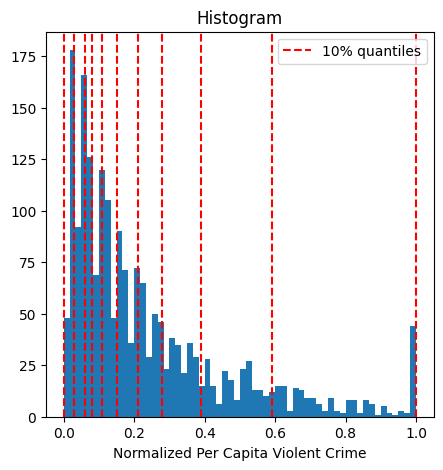

In [4]:
thres = [0] + [round(x, 2) for x in np.sort(y)[[int(len(y)/10*i) for i in range(1,10)]]] + [1]
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
for t in thres:
    ax.axvline(t, linestyle="--", c="r", label="10% quantiles"*int(t==0))
ax.hist(y, bins=60)
ax.set_xlabel("Normalized Per Capita Violent Crime")
ax.set_title("Histogram")
ax.legend()
plt.show()

By doing so, we create 10 groups based on the target value, where each group has the same number of samples.

## Evaluation functions

In [5]:
def estimate_scores(mapie_regressors, group_functions, score_functions,
                    n_train=2000,n_calib=2000,n_test=500, seed=1):
    """
    Sample a new data split, train the estimator on the training set, then
    fit the calibration on the new calibration set. The scores corresponding
    to ``score_functions`` are computing on each group of ``group_functions``.
    """
    
    x_train, y_train, x_calib, y_calib, x_test, y_test = generate_data(
        seed=seed,
        n_train=n_train,n_calib=n_calib,n_test=n_test
    )   
    scores = np.zeros((3, len(score_functions), len(group_functions)))
    for i, mapie_regressor in enumerate(mapie_regressors):
        mapie_regressor = deepcopy(mapie_regressor)
        mapie_regressor.fit(x_train, y_train).conformalize(x_calib, y_calib)
        _, y_pi = mapie_regressor.predict_interval(x_test)
        for group_num, group_fn in enumerate(group_functions):
            x_filter = group_fn(x_test, y_test)
            for score_num, score_fn in enumerate(score_functions):
                scores[i,score_num, group_num] = score_fn(
                    y=y_test[x_filter],
                    lower=y_pi[:, 0, 0][x_filter],
                    upper=y_pi[:, 1, 0][x_filter]
                )
    
    return scores


def get_scores_n_trials(
        mapies, n_trials, group_functions, group_names,
        score_functions, score_names, n_train=2000, n_calib=2000, n_test=500,
    ):
    """
    Compute ``n_trials`` evaluation scores on different dataset splits.
    """

    scores = np.zeros((n_trials, 3, len(score_functions), len(group_functions)))

    for trial in tqdm(range(n_trials)):
        scores[trial,:,:,:] = estimate_scores(
            mapies, group_functions, score_functions,
            n_train, n_calib, n_test, trial
        )
        
    method_names = ["Split", "CQR", "CCP"]
    
    scores_df = pd.DataFrame()
    for group_num, group_name in enumerate([e for g in  group_names for e in g]):
        for method_num, method_name in enumerate(method_names):
            temp_df = pd.DataFrame(
                {
                    'Method': [method_name] * n_trials, 
                    'Group name' : [group_name] * n_trials, 
                }
            )
            for score_num, score_name in enumerate(score_names):
                temp_df[score_name] = scores[:,method_num, score_num, group_num]    

            scores_df = pd.concat([scores_df,temp_df], axis=0)
            
    return scores_df.reset_index(drop=True)

## Plotting functions

In [6]:
def plot_subplot(ax, y_test_sorted, y_pred_sorted, upper_pi, lower_pi, lw,
                 color_rgb, xlabel, ylabel, title, showlegend=False):
    color = mcolors.rgb2hex(color_rgb)
    ax.plot(y_test_sorted, y_pred_sorted, lw=lw, color='black', label="Prediction" if showlegend else "")
    ax.fill_between(y_test_sorted, upper_pi, lower_pi, color=color, alpha=0.3, label='Prediction interval' if showlegend else "")
    ax.plot(y_test_sorted, upper_pi, lw=lw, color=color)
    ax.plot(y_test_sorted, lower_pi, lw=lw, color=color)
    ax.plot([0, 1], [0, 1], lw=lw, color='black', linestyle='--', label="Perfect Prediction" if showlegend else "")
    ax.set_ylim([-0.1, 1.1])
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)


def plot_score_boxplot(ax, df, score_name, group_names, color_discrete_map):
    flatten_group_names = [item for sub in group_names for item in sub]
    for i, method in enumerate(["Split", "CQR", "CCP"]):
        df_method = df[df["Method"] == method]
        color = color_discrete_map[method]
        
        ax.boxplot(
            [df_method[df_method["Group name"] == g][score_name] for g in flatten_group_names],
            positions=np.arange(len(flatten_group_names)) + (i-1) * 0.2,
            widths=0.2, patch_artist=True,
            boxprops=dict(facecolor=color), medianprops=dict(color="black"),
            labels=[g if i == 1 else "" for g in flatten_group_names]
        )

    for g in group_names[1:]:
        ax.axvline(x=flatten_group_names.index(g[0]) - 0.5, color='black', linewidth=2)
    ax.tick_params(axis='x', rotation=-45)
    ax.set_xticks(np.arange(len(flatten_group_names)))
    ax.set_xticklabels(flatten_group_names, ha='left', rotation_mode='anchor')


In [7]:
def plot_intervals(mapie_regressors, n_train, n_calib, n_test):
    x_train, y_train, x_calib, y_calib, x_test, y_test = generate_data(seed=1, n_train=n_train, n_calib=n_calib, n_test=n_test)

    sort_order = np.argsort(y_test)
    x_test_sorted = x_test[sort_order, :]
    y_test_sorted = y_test[sort_order]
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    for i, mapie_regressor in enumerate(mapie_regressors):
        mapie_regressor = deepcopy(mapie_regressor)
        mapie_regressor.fit(x_train, y_train).conformalize(x_calib, y_calib)
        y_pred_split, y_pis_split = mapie_regressor.predict_interval(x_test_sorted)
        split_lower = y_pis_split[:, 0, 0]
        split_upper = y_pis_split[:, 1, 0]
        plot_subplot(axes[i], y_test_sorted, y_pred_split, split_upper, split_lower, 1, f"C{i}", "True Price", "Predicted Price", "Split", showlegend=True)
        
        lines_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
        lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
        fig.legend(lines, labels, loc="upper right")

    plt.subplots_adjust(top=0.95, right=0.9)
    plt.show()
    
def plot_coverage_width(mapie_regressors, n_trials, group_functions, group_names, score_functions, score_names, n_train, n_calib, n_test):

    scores_df = get_scores_n_trials(mapie_regressors, n_trials, group_functions, group_names, score_functions, score_names, n_train, n_calib, n_test)
    # ============================ Plot results ============================
    for score_name in score_names:
        fig, ax = plt.subplots(figsize=(30, 10))
        cp = plt.get_cmap('tab10').colors
        color_discrete_map = dict(zip(["Split", "CQR", "CCP"], [mcolors.rgb2hex(c) for c in cp[:3]]))

        plot_score_boxplot(ax, scores_df, score_name, group_names, color_discrete_map)

        if score_name == "Coverage":
            ax.axhline(confidence_level, color='red', linewidth=3)

        ax.set_title(score_name, fontsize=22)
        ax.set_xlabel("Groups", fontsize=20)
        ax.set_ylabel(score_name, fontsize=20)
        ax.tick_params(axis='both', which='major', labelsize=20)
        
        legend_handles = [mpatches.Patch(color=color, label=method) for method, color in color_discrete_map.items()]
        fig.legend(handles=legend_handles, loc='upper right', fontsize=18)

        plt.tight_layout()
        plt.show()

## Evaluation methods and configuration

In [8]:
# scores functions
def coverage_funct(y, lower, upper):
    return np.mean((lower <= y) & (y <= upper))
def width_funct(y, lower, upper):
    return np.mean(np.abs(upper - lower))
score_functions = [coverage_funct, width_funct]
score_names = ["Coverage", "Width"]

# Groups functions: the scores will be evaluated on each one of these groups.
thres = thres = [0] + [round(x, 2) for x in np.sort(y)[[int(len(y)/10*i) for i in range(1,10)]]] + [1]

# index of the 4 columns of interest:
# 'racepctblack', 'racePctWhite', 'racePctAsian', 'racePctHisp'
group_cols = [4, 5, 6, 7]

group_functions = (
    # all dataset, for marginal evaluation
    [lambda x, y: np.ones(len(x)).astype(bool)]
    # 10 target groups
    + [lambda x, y, i=i : np.logical_and(y>=thres[i],  y <= thres[i+1]) for i in range(10)]
    # groups on ethnicity features
    + [lambda x, y, c=c, q1=q1, q2=q2 : np.logical_and(
        x[:, c] >= np.sort(X_scaled[:,c])[int(len(X_scaled)*q1)],
        x[:, c] <= np.sort(X_scaled[:,c])[int(len(X_scaled)*q2)-1])
        for c in group_cols
        for (q1, q2) in zip([0, 0.25, 0.5, 0.75], [0.25, 0.5, 0.75, 1])
    ]
)
group_names = (
    [["MARGINAL"]] 
    + [[f"Crime: {thres[i]} - {thres[i+1]}" for i in range(10)]]
    + [
        [
            f"{col_names[c]} : {q1}-{q2}%" 
            for (q1, q2) in zip([0, 25, 50, 75], [25, 50, 75, 100])
        ]
        for c in group_cols
    ]
)


# Experiments and results:

In [9]:
confidence_level = 0.8
n_train, n_calib, n_test = 650, 650, 694
n_trials = 10

# Define the model
estimator = LGBMRegressor(
    objective='quantile',
    alpha=0.5,
    random_state=random_state,
    verbose=-1,
)

# ================= Split =================
mapie_split = SplitConformalRegressor(
    estimator=deepcopy(estimator),
    confidence_level=confidence_level,
    conformity_score=AbsoluteConformityScore(sym=False),
    prefit=False,
)

# ================= CQR =================
mapie_cqr = ConformalizedQuantileRegressor(
    estimator=deepcopy(estimator),
    confidence_level=confidence_level,
)

---

## 1. Using ``GaussianCCP`` calibrator for adaptativity <u>without prior knowledge on the dataset or biases</u>

In [10]:
def make_gaussian_ccp_feature_map(n_centers=12, seed=random_state):
    """
    Build a Gaussian feature map for CCP.

    The centers and bandwidth are initialized lazily on the first call to
    ``feature_map``. In this notebook, that first call happens during
    ``conformalize(X_calib, y_calib)``, so the centers are sampled from the
    calibration set. The bandwidth is set to the median pairwise distance
    between centers, which adapts the Gaussian scale to the current data split.

    The returned features contain an intercept column plus raw Gaussian
    similarities to the sampled centers. We avoid row-normalizing these
    similarities so that their magnitude still reflects how close a point is to
    the centers.
    """
    rng = np.random.default_rng(seed)
    centers = None
    sigma = None

    def feature_map(X):
        nonlocal centers, sigma

        X = np.asarray(X, dtype=float)
        if X.ndim == 1:
            X = X.reshape(1, -1)

        if centers is None:
            n_selected = min(n_centers, len(X))
            center_idx = rng.choice(len(X), size=n_selected, replace=False)
            centers = X[center_idx]

            sigma = np.median(pairwise_distances(centers))
            sigma = max(sigma, 1e-12)

        squared_distances = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
        gaussian_features = np.exp(-squared_distances / (2 * sigma**2))

        return np.column_stack([np.ones(len(X)), gaussian_features])

    return feature_map

mapie_ccp = ConditionalSplitConformalRegressor(
    make_gaussian_ccp_feature_map(n_centers=12, seed=random_state),
    estimator=deepcopy(estimator),
    confidence_level=confidence_level,
    conformity_score=AbsoluteConformityScore(sym=False),
    prefit=False,
    randomize=True,
)

### Plotting the result

INFO:root:The predictions are ill-sorted.


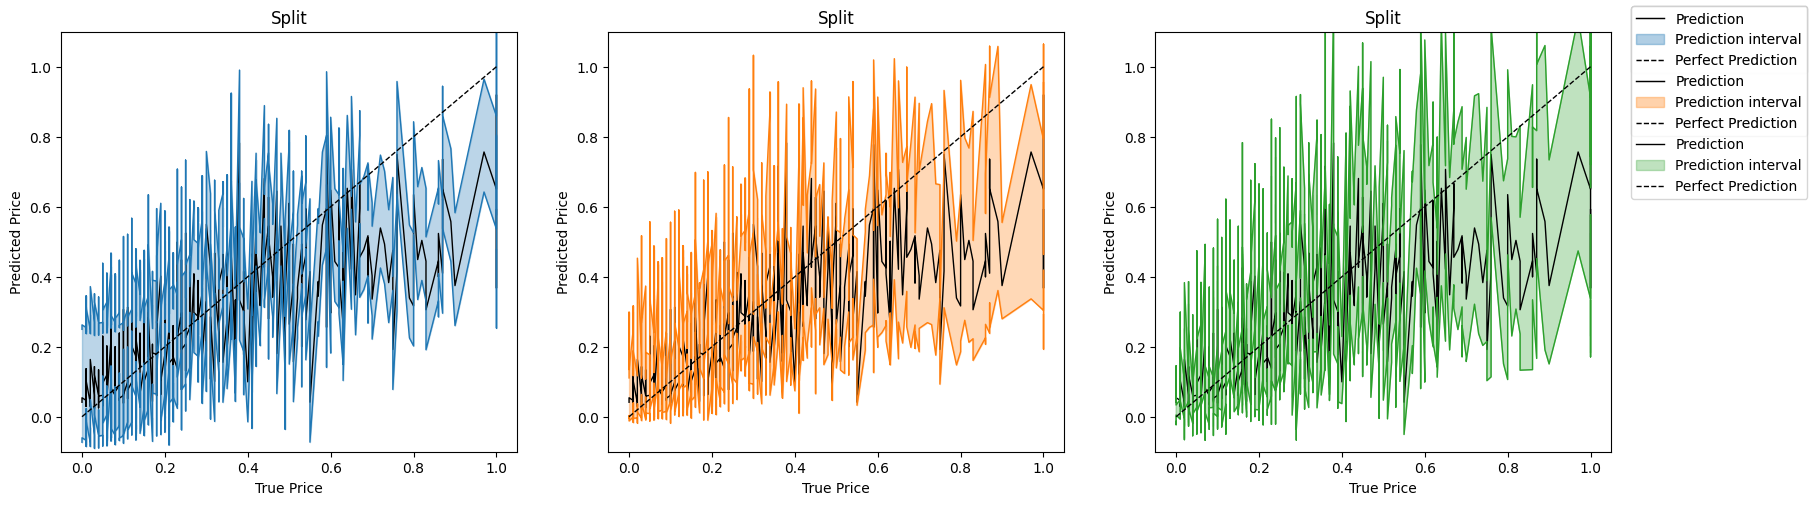

  0%|          | 0/10 [00:00<?, ?it/s]INFO:root:The predictions are ill-sorted.
INFO:root:The predictions are ill-sorted.
 20%|██        | 2/10 [00:04<00:19,  2.40s/it]INFO:root:The predictions are ill-sorted.
INFO:root:The predictions are ill-sorted.
 30%|███       | 3/10 [00:06<00:15,  2.19s/it]INFO:root:The predictions are ill-sorted.
INFO:root:The predictions are ill-sorted.
 40%|████      | 4/10 [00:08<00:12,  2.09s/it]INFO:root:The predictions are ill-sorted.
INFO:root:The predictions are ill-sorted.
 50%|█████     | 5/10 [00:10<00:10,  2.01s/it]INFO:root:The predictions are ill-sorted.
INFO:root:The predictions are ill-sorted.
 70%|███████   | 7/10 [00:15<00:06,  2.11s/it]INFO:root:The predictions are ill-sorted.
INFO:root:The predictions are ill-sorted.
 80%|████████  | 8/10 [00:17<00:04,  2.12s/it]INFO:root:The predictions are ill-sorted.
INFO:root:The predictions are ill-sorted.
 90%|█████████ | 9/10 [00:20<00:02,  2.63s/it]INFO:root:The predictions are ill-sorted.
INFO:root:

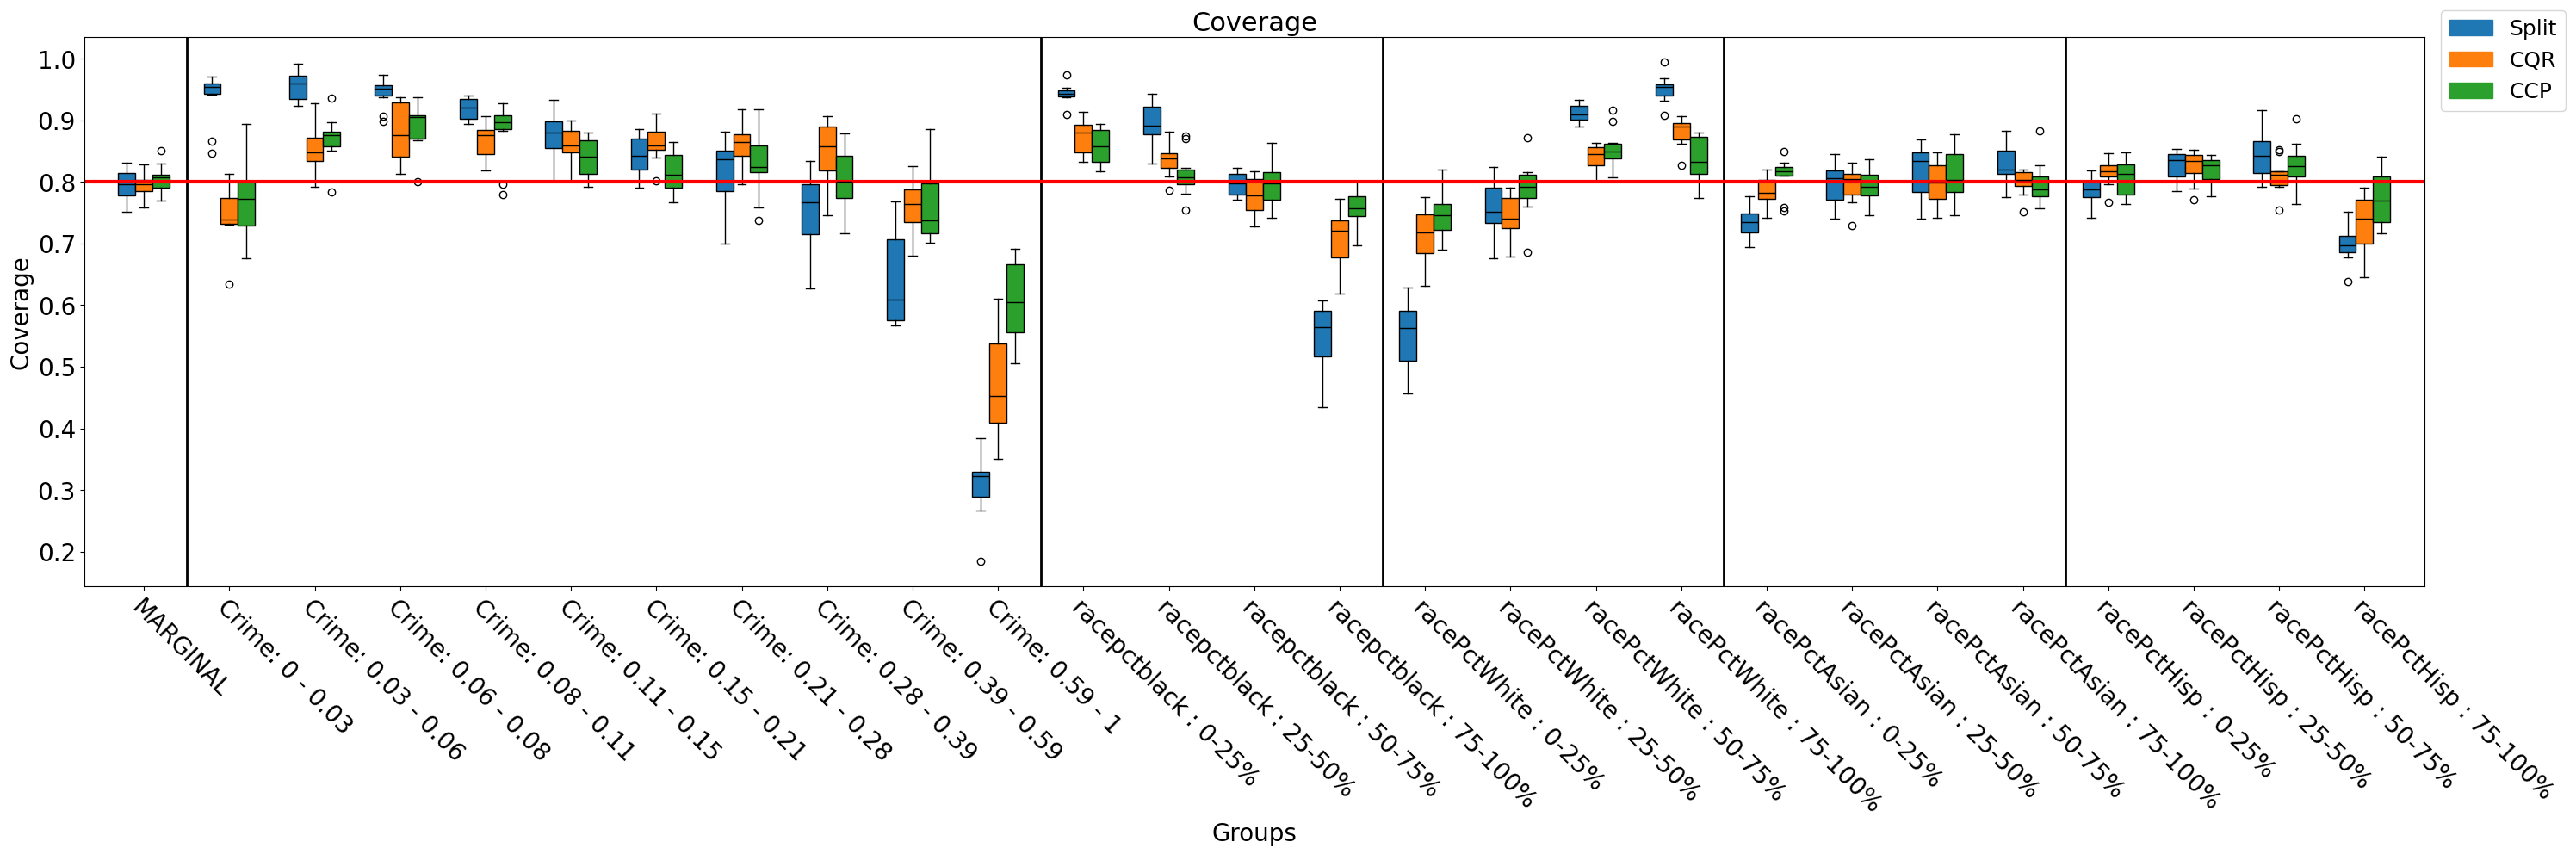

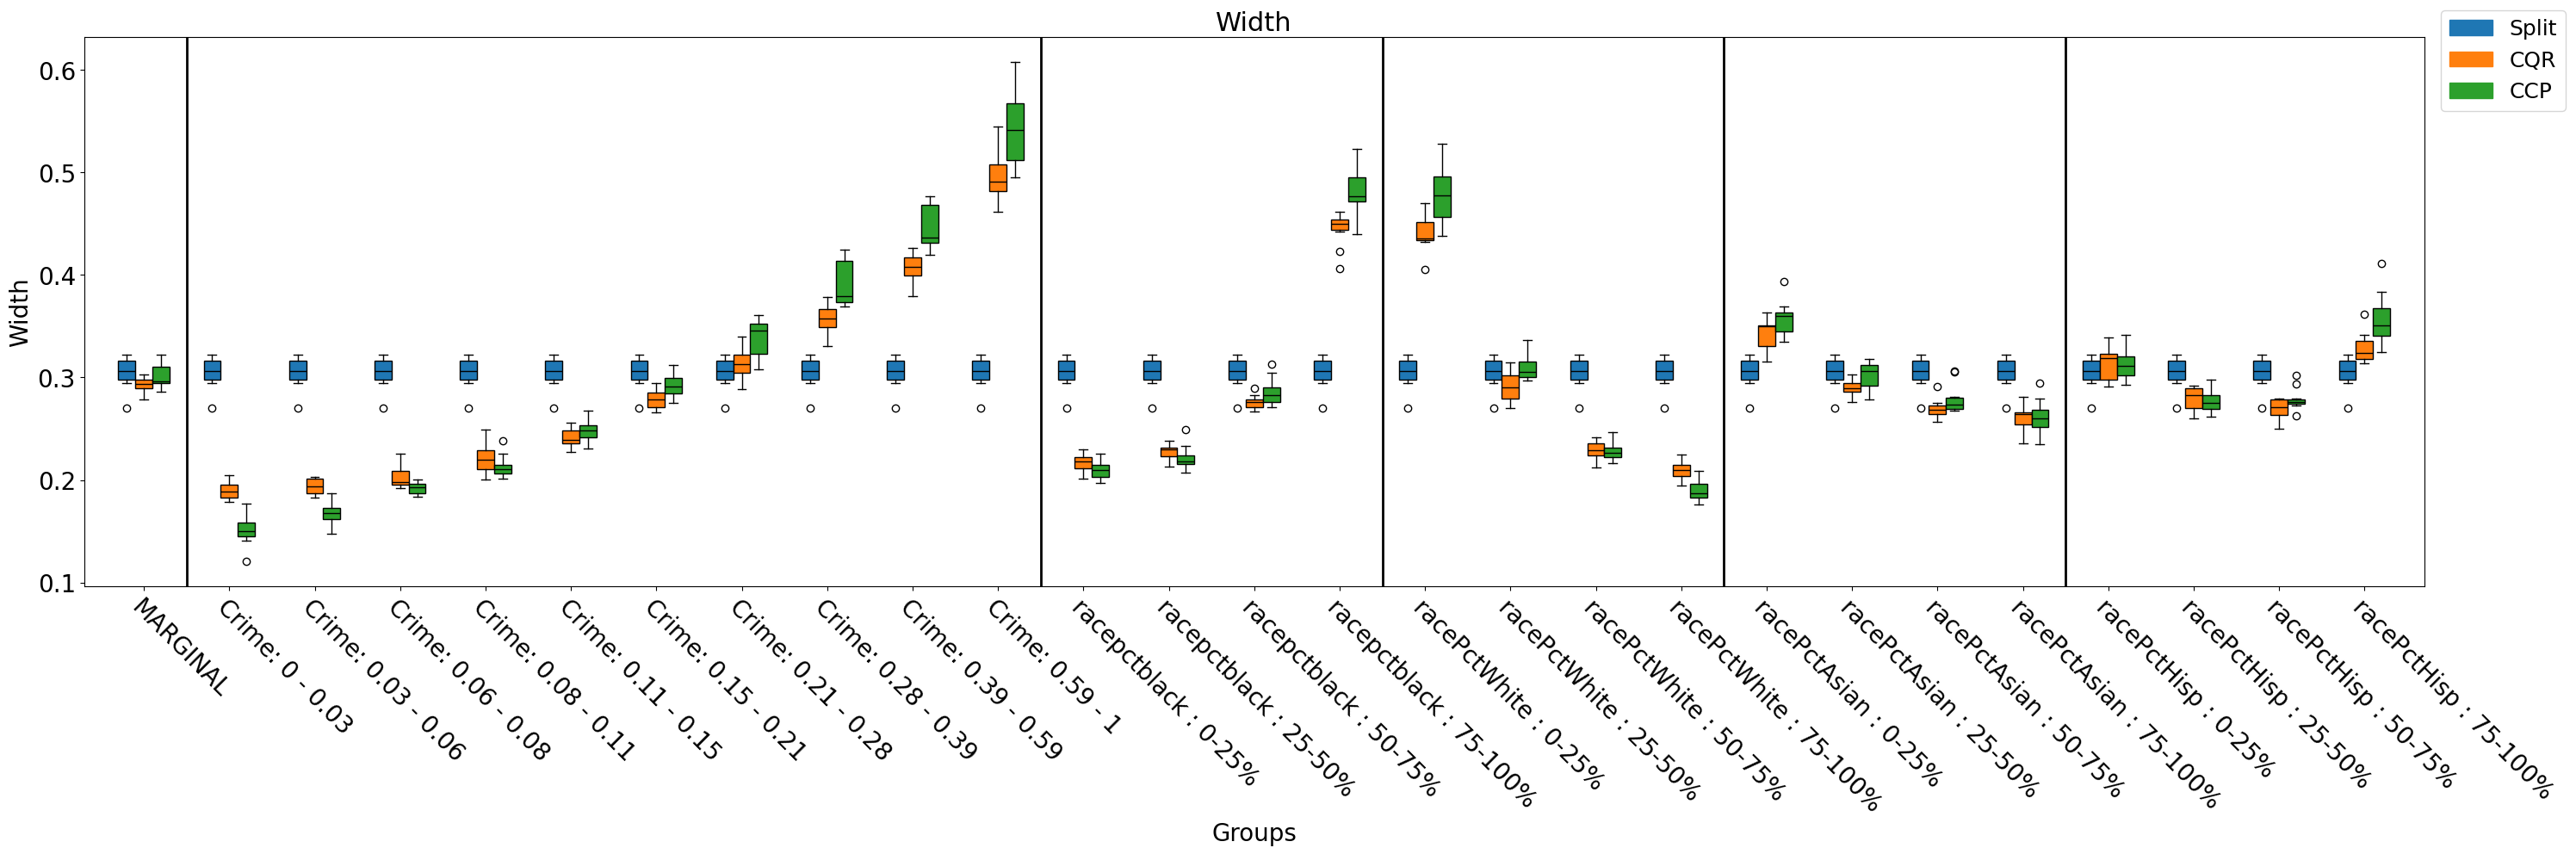

In [11]:
plot_intervals((mapie_split, mapie_cqr, mapie_ccp), n_train, n_calib, n_test)
plot_coverage_width((mapie_split, mapie_cqr, mapie_ccp), n_trials, group_functions, group_names, score_functions, score_names, n_train, n_calib, n_test)

- The method which is the more adaptative is the one with the most constant coverage.
- Here, the ``CCP`` method is the best one. We can see that the basic ``Split`` method has a strong over-coverage for small target values, and under-coverage for big target values. Moreover, it seems to have a <u>strong bias</u> on the ``'racepctblack'`` and ``'racePctWhite'``.
- The ``CQR`` method is better than the ``Split`` but suffers from the same issues.

$\to$ We managed, with ``ConditionalSplitConformalRegressor``, to have a more <u>homogenous coverage</u> on the target value, and a much <u>smaller bias on the ethnicity groups</u>.

$\to$ However its prediction time is longer than the other CP methods as it contains an optimization process.

---

## 2. Using ``CustomCCP`` calibrator for adaptativity <u>with prior knowledge about the biases</u> we want to avoid
We saw previously, that there was a strong bias on the ethnicity features (with over or under coverage for some values).

$\to$ We can use this information in ``ConditionalSplitConformalRegressor`` to fix it. Let's define a feature map with those features, to guarantee a homogenous coverage on those.
We could just add, as custom functions definition, indicatrice functions for each of the 4 groups (split using Q1, mediane and Q3 values), for each ethnicity feature. 

However, as the coverage seems to be proportional to the ethnicity value, we will also pass the specific ``X`` value.

In [12]:
def ethnicity_feature_map(X):
    """
    Build custom CCP features targeting the ethnicity groups used in the
    diagnostics.

    For each selected ethnicity feature, we split the feature values into four
    empirical quartile groups. Inside each group, the feature value itself is
    kept, and outside the group it is set to zero. This lets CCP adapt intervals
    differently across the ethnicity ranges where coverage imbalance may appear.

    The first column is an intercept, which keeps a global calibration component
    in the conditional problem. We do not row-normalize the features, so their
    scale still reflects the original standardized feature values.
    """
    X = np.asarray(X, dtype=float)
    features = [np.ones(len(X))]

    for c in group_cols:
        edges = np.quantile(X_scaled[:, c], np.linspace(0, 1, 5))
        for i, (left, right) in enumerate(zip(edges[:-1], edges[1:])):
            if i == len(edges) - 2:
                mask = (X[:, c] >= left) & (X[:, c] <= right)
            else:
                mask = (X[:, c] >= left) & (X[:, c] < right)
            features.append(X[:, c] * mask)

    return np.column_stack(features)
mapie_ccp = ConditionalSplitConformalRegressor(
    ethnicity_feature_map,
    estimator=deepcopy(estimator),
    confidence_level=confidence_level,
    conformity_score=AbsoluteConformityScore(sym=False),
    prefit=False,
)

### Plotting the result

INFO:root:The predictions are ill-sorted.


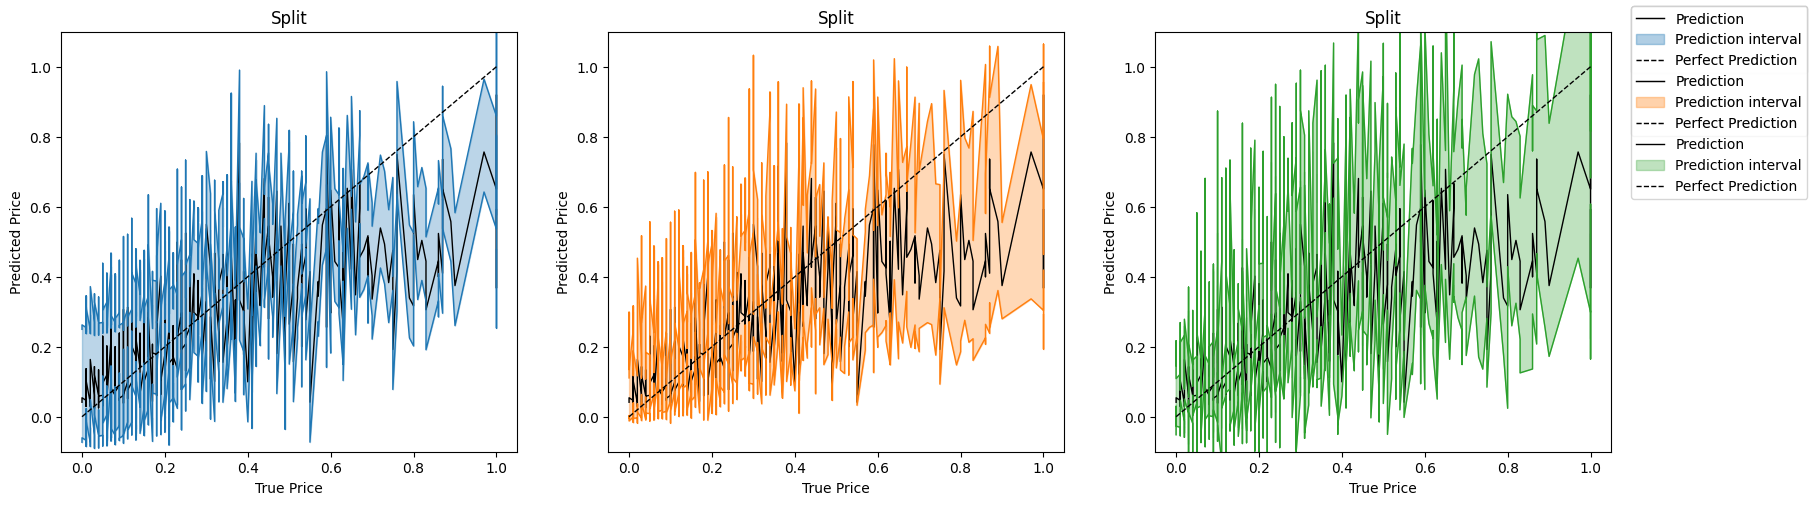

  0%|          | 0/10 [00:00<?, ?it/s]INFO:root:The predictions are ill-sorted.
INFO:root:The predictions are ill-sorted.
 20%|██        | 2/10 [00:14<01:01,  7.70s/it]INFO:root:The predictions are ill-sorted.
INFO:root:The predictions are ill-sorted.
 30%|███       | 3/10 [00:22<00:52,  7.50s/it]INFO:root:The predictions are ill-sorted.
INFO:root:The predictions are ill-sorted.
 40%|████      | 4/10 [00:30<00:47,  7.95s/it]INFO:root:The predictions are ill-sorted.
INFO:root:The predictions are ill-sorted.
 50%|█████     | 5/10 [00:37<00:37,  7.47s/it]INFO:root:The predictions are ill-sorted.
INFO:root:The predictions are ill-sorted.
 70%|███████   | 7/10 [00:59<00:28,  9.61s/it]INFO:root:The predictions are ill-sorted.
INFO:root:The predictions are ill-sorted.
 80%|████████  | 8/10 [01:10<00:20, 10.06s/it]INFO:root:The predictions are ill-sorted.
INFO:root:The predictions are ill-sorted.
 90%|█████████ | 9/10 [01:14<00:08,  8.26s/it]INFO:root:The predictions are ill-sorted.
INFO:root:

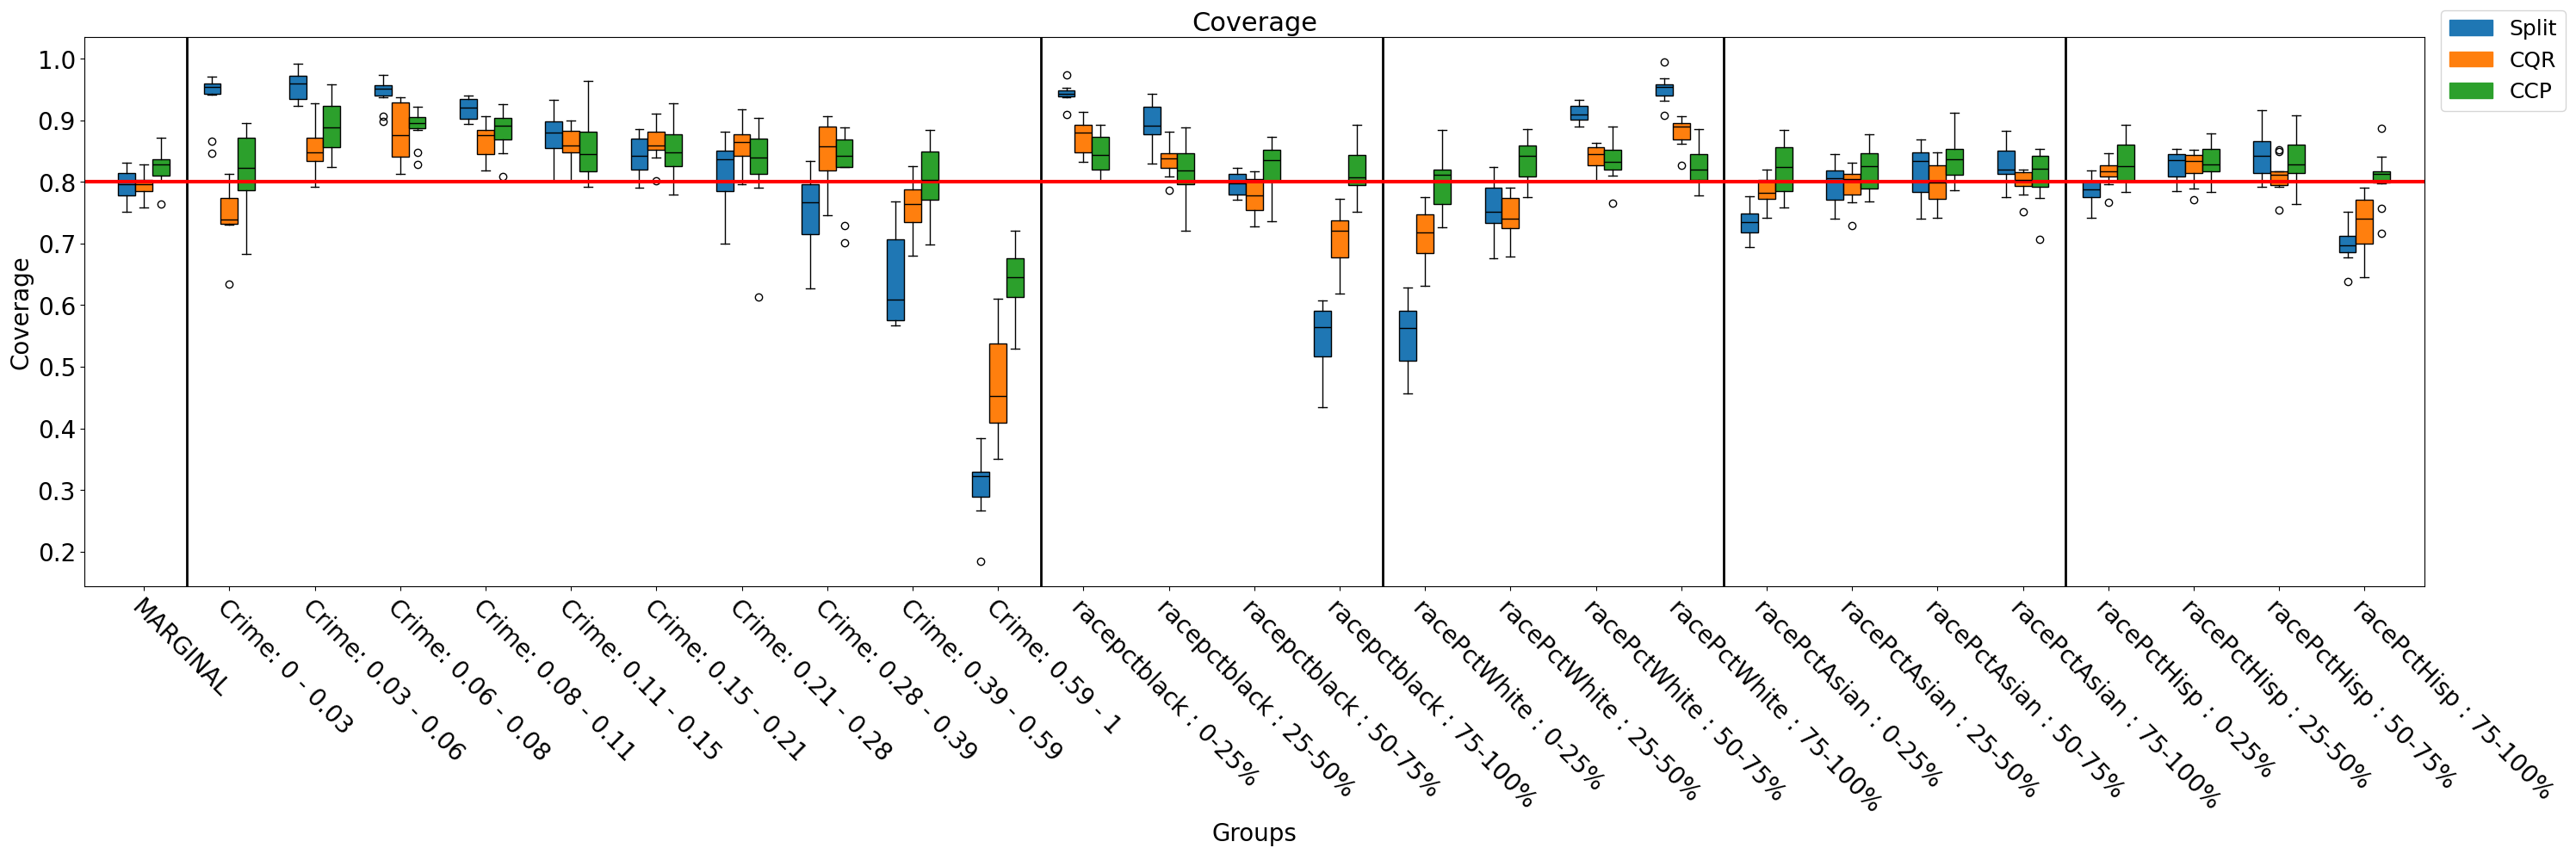

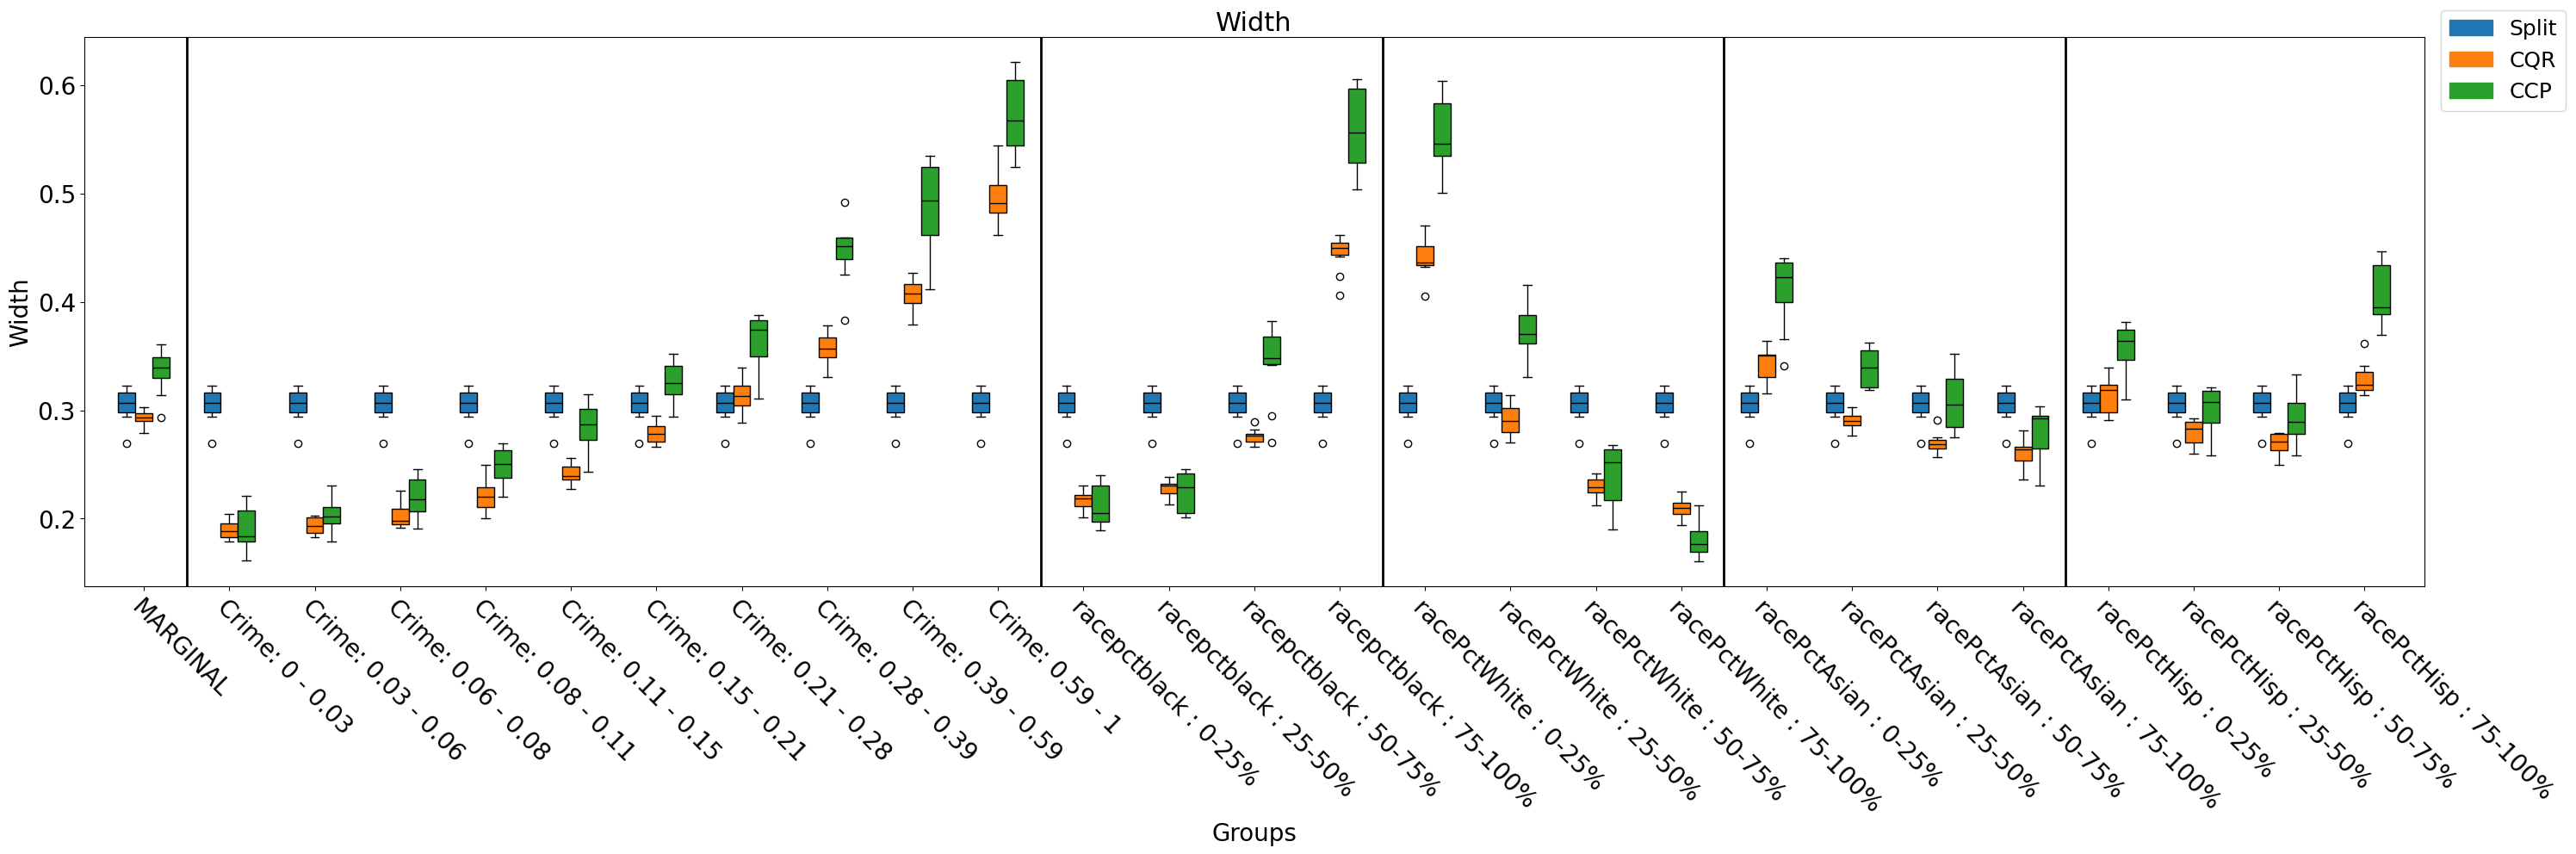

In [13]:
plot_intervals((mapie_split, mapie_cqr, mapie_ccp), n_train, n_calib, n_test)
plot_coverage_width((mapie_split, mapie_cqr, mapie_ccp), n_trials, group_functions, group_names, score_functions, score_names, n_train, n_calib, n_test)

As we expected, the coverage is now more <u>homogenous on the ethnicity groups</u>. To achieve it, the prediction intervals are now even wider than before for previously under-covered samples, and smaller on previously over-covered samples. 

$\to$ ``ConditionalSplitConformalRegressor`` can guarantee a homogenous coverage on groups of interest (thus <u>remove bias</u>), by giving to the calibrator an adapted feature map.

$\to$ Fixing this bias, almost fixed the non-homogeneity of the coverage, on the target value.

<u>Next steps</u>: the only issue to achieve an almost perfect adaptativity, is to fix the under-coverage for the biggest 10% target crime values. One idea may be to combine the two approachs we used (with indicator functions to avoid the biases and gaussian kernels for overall adaptativity), or add a new column to the calibrator, with the ``y_pred`` value to have a bigger interval for high predictions, without changing too much the smaller predictions.